# imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import FuncFormatter

# load target csv results

In [2]:
df_dataset = pd.read_csv("/NOBACKUP/aumona/projects/RF-GAP-Python/experiments/results/20260410_151311_ablation/dataset/dataset_results.csv")

# clean data names

In [3]:
DATASET_DISPLAY_NAMES = {
    "celegans": "CElegans",
    "covertype": "Covertype",
    "nsl_kdd+": "NSL-KDD+",
    "pathmnist_28": "PathMNIST",
    "pbmc": "PBMC",
    "sign_mnist": "SignMNIST",
    "tissuemnist_28": "TissueMNIST",
    "tv_news_combined": "TV News",
    "zilionis": "Zilionis",
}

# plot settings and config

In [17]:
SELECTED_DATASETS = [
    "celegans",
    "covertype",
    "nsl_kdd+",
    # "sign_mnist",
    "pathmnist_28",
    "pbmc",
    "tissuemnist_28",
    "tv_news_combined",
    "zilionis",
]

N_ROWS = 4
N_COLS = 2

# Single-column SIAM-like figure width
FIG_WIDTH = 3.3
FIG_HEIGHT_PER_ROW = 1.25

SAVE_BASENAME = "dataset_ablation_grid_single_column"
FIG_DIR = Path("./compiled_dataset_ablation_figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 6.5,
    "axes.labelsize": 7,
    "axes.titlesize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6.5,
    "lines.linewidth": 1.2,
    "axes.spines.top": False,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.01,
})

# utils

In [18]:
def summarize_curve(df: pd.DataFrame, y_col: str) -> pd.DataFrame:
    out = (
        df.groupby(["dataset", "train_fraction", "n_train_subset"], as_index=False)[y_col]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    out["se"] = out["std"].fillna(0.0) / np.sqrt(out["count"])
    out["lower"] = out["mean"] - out["se"]
    out["upper"] = out["mean"] + out["se"]
    return out


def format_rough_n(n: float) -> str:
    n = int(round(n))
    if n >= 1_000_000:
        s = f"{n / 1_000_000:.1f}M"
        return s.replace(".0M", "M")
    if n >= 1_000:
        return f"{n / 1_000:.0f}k"
    return str(n)


def rough_count_formatter(x, pos):
    return format_rough_n(x)


def format_mem_tick(x, pos):
    if x >= 1_000:
        s = f"{x / 1_000:.1f}K"
        return s.replace(".0K", "K")
    return f"{int(round(x))}"


def dataset_plot_title(dataset_key: str) -> str:
    return DATASET_DISPLAY_NAMES.get(dataset_key, dataset_key)

# build plotting dataframe and summaries

In [19]:
assert "df_dataset" in globals(), "Please load df_dataset before running this cell."

df_plot = df_dataset.copy()

df_plot["kernel_pipeline_time_s"] = (
    df_plot["cache_build_time_s"].fillna(0)
    + df_plot["q_build_time_s"].fillna(0)
    + df_plot["full_kernel_time_s"].fillna(0)
)

df_plot["kernel_pipeline_peak_mb"] = df_plot[
    ["cache_build_peak_mb", "q_build_peak_mb", "full_kernel_peak_mb"]
].fillna(0).max(axis=1)

if "status" in df_plot.columns:
    df_plot = df_plot[df_plot["status"] == "ok"].copy()

available_datasets = sorted(df_plot["dataset"].unique())
missing = [ds for ds in SELECTED_DATASETS if ds not in available_datasets]
if missing:
    raise ValueError(f"These selected datasets are missing from df_plot: {missing}")

PLOT_DATASETS = SELECTED_DATASETS

time_summary = summarize_curve(df_plot, "kernel_pipeline_time_s")
mem_summary = summarize_curve(df_plot, "kernel_pipeline_peak_mb")

print("Datasets to plot:", PLOT_DATASETS)
display(time_summary.head())
display(mem_summary.head())

Datasets to plot: ['celegans', 'covertype', 'nsl_kdd+', 'pathmnist_28', 'pbmc', 'tissuemnist_28', 'tv_news_combined', 'zilionis']


,index,dataset,train_fraction,n_train_subset,mean,std,count,se,lower,upper
0,0,celegans,0.1,4918,0.302205,0.000054,5,0.000024,0.302180,0.302229
1,1,celegans,0.2,9836,0.663409,0.022597,5,0.010106,0.653303,0.673515
2,2,celegans,0.3,14755,1.225366,0.044902,5,0.020081,1.205286,1.245447
3,3,celegans,0.4,19673,2.021689,0.070230,5,0.031408,1.990281,2.053097
4,4,celegans,0.5,24592,2.911496,0.062914,5,0.028136,2.883360,2.939632


,index,dataset,train_fraction,n_train_subset,mean,std,count,se,lower,upper
0,0,celegans,0.1,4918,4.801563,10.697315,5,4.783985,0.017578,9.585547
1,1,celegans,0.2,9836,21.442969,47.906446,5,21.424414,0.018555,42.867383
2,2,celegans,0.3,14755,198.661719,53.258494,5,23.817923,174.843796,222.479641
3,3,celegans,0.4,19673,379.795313,6.911227,5,3.090795,376.704518,382.886107
4,4,celegans,0.5,24592,585.947656,7.808920,5,3.492255,582.455401,589.439911


# plot dataset ablation

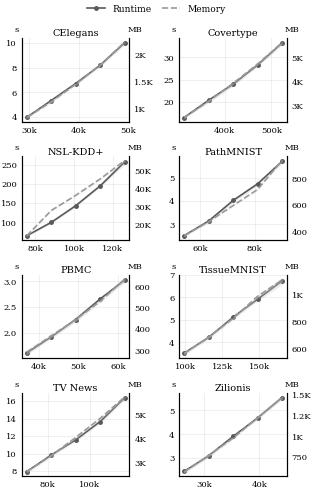

In [26]:
n_panels = len(PLOT_DATASETS)
n_slots = N_ROWS * N_COLS
if n_panels > n_slots:
    raise ValueError(f"Grid too small: {n_panels} datasets but only {n_slots} slots.")

# Softer grayscale style for the dataset sweep
runtime_color = "0.35"
memory_color = "0.60"
band_runtime_color = "0.78"
band_memory_color = "0.88"

TAIL_K = 5

fig, axes = plt.subplots(
    N_ROWS,
    N_COLS,
    figsize=(FIG_WIDTH, FIG_HEIGHT_PER_ROW * N_ROWS),
    squeeze=False
)

axes_flat = axes.ravel()
legend_handles = None

for i, dataset_name in enumerate(PLOT_DATASETS):
    ax1 = axes_flat[i]
    ax2 = ax1.twinx()

    dt = (
        time_summary[time_summary["dataset"] == dataset_name]
        .copy()
        .sort_values("n_train_subset")
        .tail(TAIL_K)
    )
    dm = (
        mem_summary[mem_summary["dataset"] == dataset_name]
        .copy()
        .sort_values("n_train_subset")
        .tail(TAIL_K)
    )

    x_t = dt["n_train_subset"].to_numpy()
    y_t = dt["mean"].to_numpy()
    lo_t = dt["lower"].to_numpy()
    up_t = dt["upper"].to_numpy()

    x_m = dm["n_train_subset"].to_numpy()
    y_m = dm["mean"].to_numpy()
    lo_m = dm["lower"].to_numpy()
    up_m = dm["upper"].to_numpy()

    # Error bands
    ax1.fill_between(x_t, lo_t, up_t, color=band_runtime_color, alpha=0.25, zorder=1)
    ax2.fill_between(x_m, lo_m, up_m, color=band_memory_color, alpha=0.22, zorder=1)

    # Curves
    l1, = ax1.plot(
        x_t, y_t,
        color=runtime_color,
        linestyle="-",
        marker="o",
        markersize=2.5,
        linewidth=1.2,
        label="Runtime",
        zorder=3,
    )
    l2, = ax2.plot(
        x_m, y_m,
        color=memory_color,
        linestyle="--",
        linewidth=1.2,
        label="Memory",
        zorder=3,
    )

    ax1.set_title(dataset_plot_title(dataset_name), pad=1.5)

    ax1.xaxis.set_major_formatter(FuncFormatter(rough_count_formatter))
    ax2.yaxis.set_major_formatter(FuncFormatter(format_mem_tick))
    ax1.grid(True, alpha=0.18, zorder=0)

    # No axis labels
    ax1.set_xlabel("")
    ax1.set_ylabel("")
    ax2.set_ylabel("")

    # Ticks: all black
    ax1.tick_params(axis="x", which="both", length=0, colors="black")
    ax1.tick_params(axis="y", which="both", length=0, colors="black")
    ax2.tick_params(axis="y", which="both", length=0, colors="black", labelright=True)

    # Keep default axis lines, only show needed spines
    ax1.spines["left"].set_visible(True)
    ax1.spines["bottom"].set_visible(True)
    ax2.spines["right"].set_visible(True)

    # Compact x ticks
    ax1.locator_params(axis="x", nbins=3)

    # Small unit labels above the two y-axes
    ax1.text(
        -0.05, 1.05, "s",
        transform=ax1.transAxes,
        ha="center", va="bottom",
        fontsize=6, color="black"
    )
    ax2.text(
        1.05, 1.05, "MB",
        transform=ax2.transAxes,
        ha="center", va="bottom",
        fontsize=6, color="black"
    )

    if legend_handles is None:
        legend_handles = [l1, l2]

for j in range(n_panels, n_slots):
    axes_flat[j].axis("off")

fig.legend(
    legend_handles,
    ["Runtime", "Memory"],
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 1.005),
    handlelength=2.0,
    columnspacing=1.2,
)

plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.965])

out_base = FIG_DIR / f"{SAVE_BASENAME}_tail{TAIL_K}"
fig.savefig(out_base.with_suffix(".pdf"))
fig.savefig(out_base.with_suffix(".png"), dpi=300)

plt.show()

# quick summary table for sanity check

In [27]:
summary_table = (
    df_plot.groupby("dataset", as_index=False)
    .agg(
        n_train_max=("n_train_subset", "max"),
        time_max_s=("kernel_pipeline_time_s", "max"),
        mem_max_mb=("kernel_pipeline_peak_mb", "max"),
    )
)

summary_table["dataset_display"] = summary_table["dataset"].map(DATASET_DISPLAY_NAMES)
display(summary_table.sort_values("dataset_display"))

,dataset,n_train_max,time_max_s,mem_max_mb,dataset_display
0,celegans,49184,10.255138,2250.996094,CElegans
1,covertype,522910,34.157743,5695.527344,Covertype
2,nsl_kdd+,125973,271.973461,55998.660156,NSL-KDD+
4,pbmc,61695,3.159003,646.359375,PBMC
3,pathmnist_28,89996,5.833319,949.304688,PathMNIST
5,sign_mnist,27455,0.964784,132.476562,SignMNIST
7,tv_news_combined,116716,16.647609,5782.109375,TV News
6,tissuemnist_28,165466,7.086829,1136.632812,TissueMNIST
8,zilionis,44072,5.665036,1492.890625,Zilionis
